In [1]:
# ============================================================
# Project: Product Optimization & Revenue Contribution Analysis
# Company: Afficionado Coffee Roasters
# Tool: Python (Pandas, Matplotlib, Seaborn)
# Internship: Unified Mentor
# ============================================================

In [2]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset from Excel file

df = pd.read_excel('Afficionado Coffee Roasters.xlsx')

print("✅ Dataset loaded successfully!")
print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

✅ Dataset loaded successfully!
Total Rows    : 149,116
Total Columns : 11


In [4]:
# View first 5 rows to understand data structure

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
# Check column names and their data types

print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
transaction_id        int64
year                  int64
transaction_time     object
transaction_qty       int64
store_id              int64
store_location          str
product_id            int64
unit_price          float64
product_category        str
product_type            str
product_detail          str
dtype: object


In [6]:
# Check for missing values in each column

print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")

Missing Values per Column:
transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

Total Missing Values: 0


In [8]:
# Check basic statistics of numerical columns

print("Basic Statistics:")
df[['transaction_qty', 'unit_price']].describe()

Basic Statistics:


,transaction_qty,unit_price
count,149116.00,149116.00
mean,1.44,3.38
std,0.54,2.66
min,1.00,0.80
25%,1.00,2.50
50%,1.00,3.00
75%,2.00,3.75
max,8.00,45.00


In [9]:
# Check unique values in categorical columns

print(f"Total Unique Products  : {df['product_id'].nunique()}")
print(f"Total Unique Categories: {df['product_category'].nunique()}")
print(f"Total Unique Stores    : {df['store_location'].nunique()}")

print(f"\nProduct Categories:")
print(df['product_category'].unique())

print(f"\nStore Locations:")
print(df['store_location'].unique())

Total Unique Products  : 80
Total Unique Categories: 9
Total Unique Stores    : 3

Product Categories:
<ArrowStringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

Store Locations:
<ArrowStringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str


In [10]:
# Validate data quality as per project instructions

print("Data Validation Checks:")
print("-" * 40)

# Check 1: Negative quantities
neg_qty = df[df['transaction_qty'] <= 0]
print(f"Negative Quantities : {len(neg_qty)}")

# Check 2: Negative prices
neg_price = df[df['unit_price'] <= 0]
print(f"Negative Prices     : {len(neg_price)}")

# Check 3: Price range
print(f"\nPrice Range:")
print(f"Minimum Price : ${df['unit_price'].min():.2f}")
print(f"Maximum Price : ${df['unit_price'].max():.2f}")
print(f"Average Price : ${df['unit_price'].mean():.2f}")

print("\n✅ Data Validation Complete!")
print("✅ Data is clean and ready for analysis!")

Data Validation Checks:
----------------------------------------
Negative Quantities : 0
Negative Prices     : 0

Price Range:
Minimum Price : $0.80
Maximum Price : $45.00
Average Price : $3.38

✅ Data Validation Complete!
✅ Data is clean and ready for analysis!


In [11]:
# ============================================================
# STEP 2: Revenue Computation
# ============================================================

# Calculate revenue for each transaction
df['revenue'] = df['transaction_qty'] * df['unit_price']

print("✅ Revenue column created successfully!")
print(f"\nSample Revenue Calculation:")
print(f"Row 0: {df['transaction_qty'][0]} qty × ${df['unit_price'][0]:.2f} = ${df['revenue'][0]:.2f}")
print(f"Row 1: {df['transaction_qty'][1]} qty × ${df['unit_price'][1]:.2f} = ${df['revenue'][1]:.2f}")
print(f"Row 2: {df['transaction_qty'][2]} qty × ${df['unit_price'][2]:.2f} = ${df['revenue'][2]:.2f}")

print(f"\nTotal Revenue Summary:")
print(f"Total Revenue  : ${df['revenue'].sum():,.2f}")
print(f"Average Revenue: ${df['revenue'].mean():.2f}")
print(f"Min Revenue    : ${df['revenue'].min():.2f}")
print(f"Max Revenue    : ${df['revenue'].max():.2f}")

✅ Revenue column created successfully!

Sample Revenue Calculation:
Row 0: 2 qty × $3.00 = $6.00
Row 1: 2 qty × $3.10 = $6.20
Row 2: 2 qty × $4.50 = $9.00

Total Revenue Summary:
Total Revenue  : $698,812.33
Average Revenue: $4.69
Min Revenue    : $0.80
Max Revenue    : $360.00


In [13]:
# ============================================================
# STEP 3: Product Popularity Analysis
# ============================================================

# Calculate total units sold per product
product_popularity = df.groupby('product_detail')['transaction_qty'].sum()
product_popularity = product_popularity.reset_index()
product_popularity.columns = ['product', 'total_units_sold']

# Sort by units sold - highest first
product_popularity = product_popularity.sort_values(
    'total_units_sold', ascending=False
).reset_index(drop=True)

# Add rank column
product_popularity['rank'] = product_popularity.index + 1

print("✅ Product Popularity Analysis Complete!")
print(f"\nTotal Products Analyzed: {len(product_popularity)}")
print(f"\nTop 10 Best Selling Products:")
print(product_popularity.head(10).to_string(index=False))

✅ Product Popularity Analysis Complete!

Total Products Analyzed: 80

Top 10 Best Selling Products:
                    product  total_units_sold  rank
               Earl Grey Rg              4708     1
          Dark chocolate Lg              4668     2
    Morning Sunrise Chai Rg              4643     3
                      Latte              4602     4
              Peppermint Rg              4564     5
  Columbian Medium Roast Rg              4547     6
  Traditional Blend Chai Rg              4512     7
                   Latte Rg              4497     8
Our Old Time Diner Blend Sm              4484     9
      Serenity Green Tea Rg              4477    10


In [14]:
# Identify bottom 10 least selling products

print("Bottom 10 Least Selling Products:")
print(product_popularity.tail(10).to_string(index=False))

Bottom 10 Least Selling Products:
                     product  total_units_sold  rank
      Traditional Blend Chai               153    71
                 Lemon Grass               152    72
        Primo Espresso Roast               150    73
                 Chili Mayan               148    74
      Columbian Medium Roast               148    75
       Jamacian Coffee River               146    76
                   Earl Grey               142    77
Guatemalan Sustainably Grown               134    78
       Spicy Eye Opener Chai               122    79
              Dark chocolate               118    80


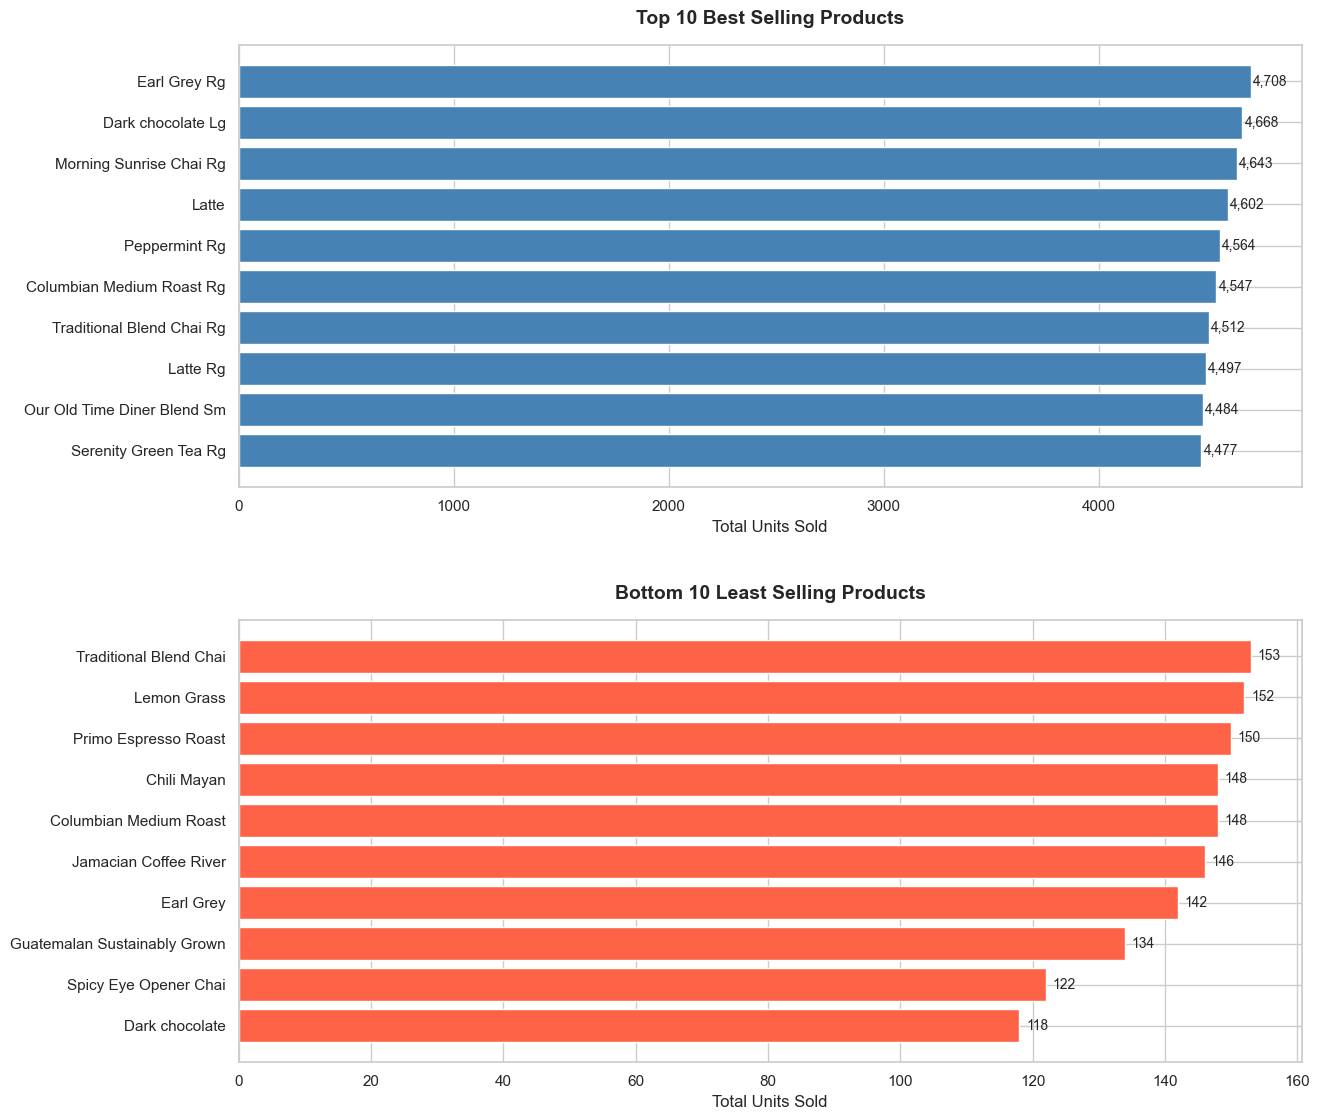

✅ Chart saved as product_popularity.png


In [15]:
# Visualize top 10 and bottom 10 products by sales volume

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10 products
top10 = product_popularity.head(10)
axes[0].barh(top10['product'], top10['total_units_sold'], 
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Best Selling Products', 
                   fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Units Sold')
axes[0].invert_yaxis()
for i, v in enumerate(top10['total_units_sold']):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=10)

# Bottom 10 products
bottom10 = product_popularity.tail(10)
axes[1].barh(bottom10['product'], bottom10['total_units_sold'], 
             color='tomato', edgecolor='white')
axes[1].set_title('Bottom 10 Least Selling Products', 
                   fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Units Sold')
axes[1].invert_yaxis()
for i, v in enumerate(bottom10['total_units_sold']):
    axes[1].text(v + 1, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout(pad=3)
plt.savefig('product_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as product_popularity.png")

In [16]:
# ============================================================
# STEP 4: Revenue Contribution Analysis
# ============================================================

# Calculate total revenue per product
product_revenue = df.groupby('product_detail')['revenue'].sum()
product_revenue = product_revenue.reset_index()
product_revenue.columns = ['product', 'total_revenue']

# Sort by revenue - highest first
product_revenue = product_revenue.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

# Add revenue rank
product_revenue['revenue_rank'] = product_revenue.index + 1

# Calculate revenue share percentage
total_revenue = product_revenue['total_revenue'].sum()
product_revenue['revenue_share_%'] = (
    product_revenue['total_revenue'] / total_revenue * 100
).round(2)

print("✅ Revenue Contribution Analysis Complete!")
print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"\nTop 10 Products by Revenue:")
print(product_revenue.head(10).to_string(index=False))

✅ Revenue Contribution Analysis Complete!

Total Revenue: $698,812.33

Top 10 Products by Revenue:
                     product  total_revenue  revenue_rank  revenue_share_%
Sustainably Grown Organic Lg       21151.75             1             3.03
           Dark chocolate Lg       21006.00             2             3.01
                    Latte Rg       19112.25             3             2.73
               Cappuccino Lg       17641.75             4             2.52
     Morning Sunrise Chai Lg       17384.00             5             2.49
                       Latte       17257.50             6             2.47
    Jamaican Coffee River Lg       16481.25             7             2.36
Sustainably Grown Organic Rg       16233.75             8             2.32
                  Cappuccino       15997.50             9             2.29
                Brazilian Lg       15109.50            10             2.16


In [17]:
# Compare volume rank vs revenue rank per product

# Merge popularity and revenue dataframes
comparison = product_popularity.merge(
    product_revenue[['product', 'revenue_rank', 
                     'total_revenue', 'revenue_share_%']],
    on='product'
)

# Calculate rank difference
comparison['rank_difference'] = (
    comparison['rank'] - comparison['revenue_rank']
)

print("Volume Rank vs Revenue Rank Comparison:")
print(f"\nTop 10 by Sales Volume with Revenue Rank:")
print(comparison.head(10)[
    ['product', 'total_units_sold', 'rank', 
     'total_revenue', 'revenue_rank', 'rank_difference']
].to_string(index=False))

Volume Rank vs Revenue Rank Comparison:

Top 10 by Sales Volume with Revenue Rank:
                    product  total_units_sold  rank  total_revenue  revenue_rank  rank_difference
               Earl Grey Rg              4708     1       11770.00            26              -25
          Dark chocolate Lg              4668     2       21006.00             2                0
    Morning Sunrise Chai Rg              4643     3       11607.50            29              -26
                      Latte              4602     4       17257.50             6               -2
              Peppermint Rg              4564     5       11410.00            30              -25
  Columbian Medium Roast Rg              4547     6       11367.50            31              -25
  Traditional Blend Chai Rg              4512     7       11280.00            32              -25
                   Latte Rg              4497     8       19112.25             3                5
Our Old Time Diner Blend Sm        

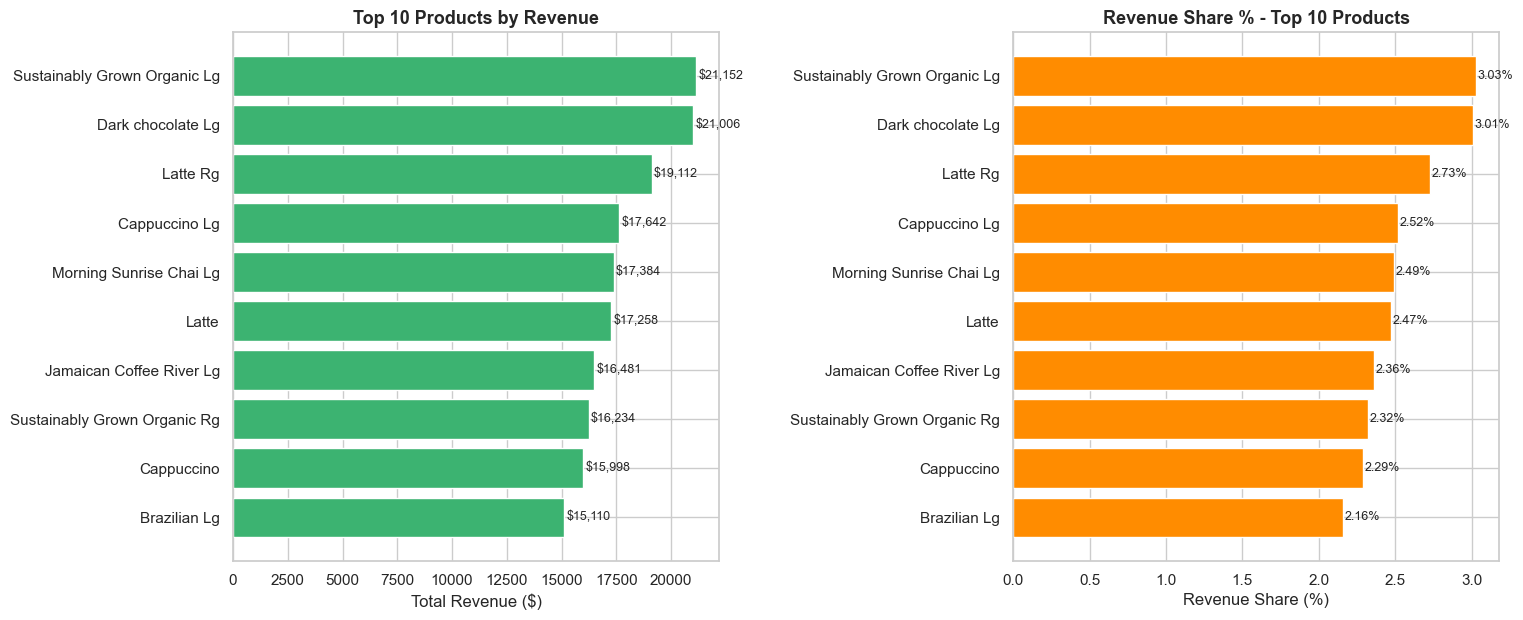

✅ Chart saved as revenue_contribution.png


In [18]:
# Visualize top 10 products by revenue contribution

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Top 10 by Revenue
top10_rev = product_revenue.head(10)
axes[0].barh(top10_rev['product'], top10_rev['total_revenue'],
             color='mediumseagreen', edgecolor='white')
axes[0].set_title('Top 10 Products by Revenue',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].invert_yaxis()
for i, v in enumerate(top10_rev['total_revenue']):
    axes[0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

# Chart 2: Revenue Share % - Top 10
axes[1].barh(top10_rev['product'], top10_rev['revenue_share_%'],
             color='darkorange', edgecolor='white')
axes[1].set_title('Revenue Share % - Top 10 Products',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue Share (%)')
axes[1].invert_yaxis()
for i, v in enumerate(top10_rev['revenue_share_%']):
    axes[1].text(v + 0.01, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout(pad=3)
plt.savefig('revenue_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as revenue_contribution.png")


In [19]:
# ============================================================
# STEP 5: Category & Product-Type Performance
# ============================================================

# Calculate revenue by product category
category_revenue = df.groupby('product_category').agg(
    total_revenue=('revenue', 'sum'),
    total_units=('transaction_qty', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Calculate revenue share per category
category_revenue['revenue_share_%'] = (
    category_revenue['total_revenue'] / 
    category_revenue['total_revenue'].sum() * 100
).round(2)

# Sort by revenue
category_revenue = category_revenue.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

print("✅ Category Analysis Complete!")
print(f"\nRevenue by Category:")
print(category_revenue.to_string(index=False))

✅ Category Analysis Complete!

Revenue by Category:
  product_category  total_revenue  total_units  total_transactions  revenue_share_%
            Coffee      269952.45        89250               58416            38.63
               Tea      196405.95        69737               45449            28.11
            Bakery       82315.64        23214               22796            11.78
Drinking Chocolate       72416.00        17457               11468            10.36
      Coffee beans       40085.25         1828                1753             5.74
           Branded       13607.00          776                 747             1.95
         Loose Tea       11213.60         1210                1210             1.60
          Flavours        8408.80        10511                6790             1.20
Packaged Chocolate        4407.64          487                 487             0.63


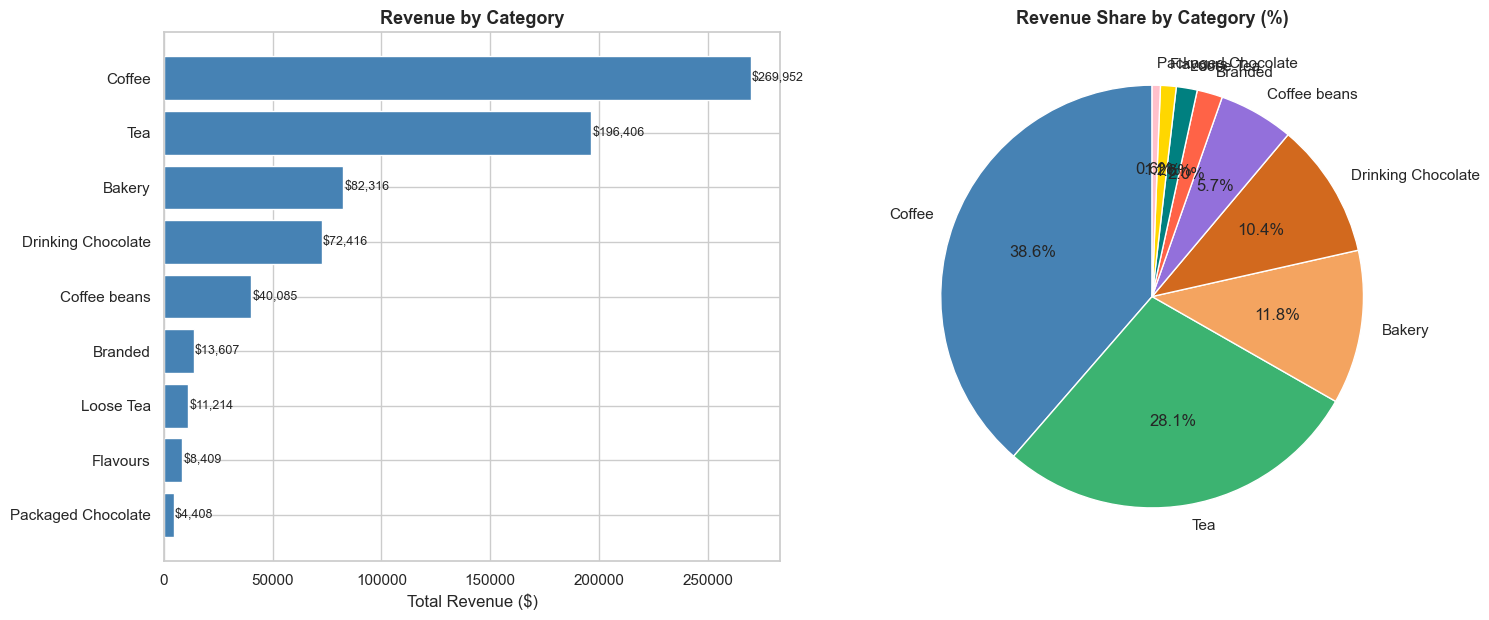

✅ Chart saved as category_revenue.png


In [20]:
# Visualize category revenue distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Revenue by Category - Bar Chart
axes[0].barh(category_revenue['product_category'],
             category_revenue['total_revenue'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Revenue by Category',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].invert_yaxis()
for i, v in enumerate(category_revenue['total_revenue']):
    axes[0].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

# Chart 2: Revenue Share - Pie Chart
colors = ['steelblue', 'mediumseagreen', 'sandybrown',
          'chocolate', 'mediumpurple', 'tomato',
          'teal', 'gold', 'pink']
axes[1].pie(category_revenue['revenue_share_%'],
            labels=category_revenue['product_category'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Revenue Share by Category (%)',
                   fontsize=13, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig('category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as category_revenue.png")

In [21]:
# Revenue by product type within each category

product_type_revenue = df.groupby(
    ['product_category', 'product_type']
)['revenue'].sum().reset_index()

product_type_revenue.columns = [
    'category', 'product_type', 'total_revenue'
]

# Calculate share within each category
product_type_revenue['category_share_%'] = (
    product_type_revenue.groupby('category')['total_revenue']
    .transform(lambda x: (x / x.sum() * 100).round(2))
)

# Sort by category and revenue
product_type_revenue = product_type_revenue.sort_values(
    ['category', 'total_revenue'], ascending=[True, False]
).reset_index(drop=True)

print("✅ Product Type Analysis Complete!")
print(f"\nRevenue by Product Type within Category:")
print(product_type_revenue.to_string(index=False))

✅ Product Type Analysis Complete!

Revenue by Product Type within Category:
          category          product_type  total_revenue  category_share_%
            Bakery                 Scone       36866.12             44.79
            Bakery                Pastry       25655.99             31.17
            Bakery              Biscotti       19793.53             24.05
           Branded            Housewares        7444.00             54.71
           Branded              Clothing        6163.00             45.29
            Coffee      Barista Espresso       91406.20             33.86
            Coffee Gourmet brewed coffee       70034.60             25.94
            Coffee Premium brewed coffee       38781.15             14.37
            Coffee Organic brewed coffee       37746.50             13.98
            Coffee           Drip coffee       31984.00             11.85
      Coffee beans         Premium Beans       14583.50             36.38
      Coffee beans         Organic B

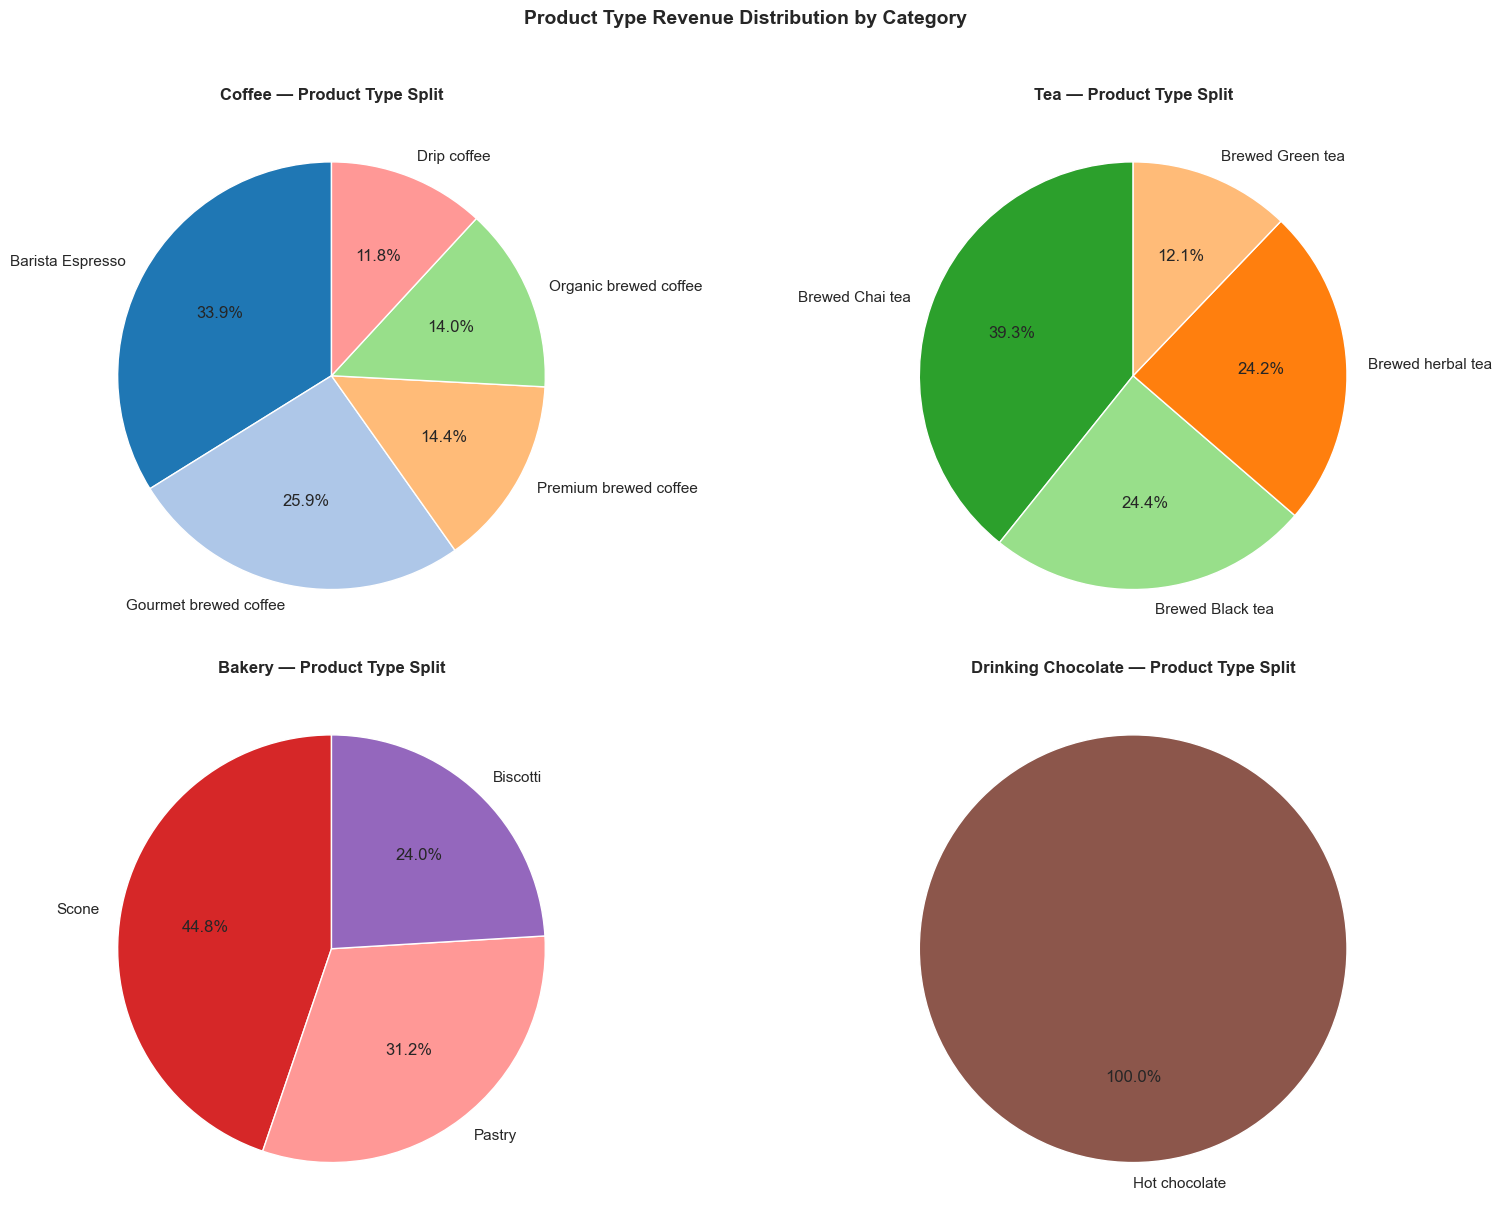

✅ Chart saved as product_type_analysis.png


In [23]:
# Visualize top product types within main categories

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categories = ['Coffee', 'Tea', 'Bakery', 'Drinking Chocolate']
colors_list = [
    ['#1f77b4','#aec7e8','#ffbb78','#98df8a','#ff9896'],
    ['#2ca02c','#98df8a','#ff7f0e','#ffbb78'],
    ['#d62728','#ff9896','#9467bd'],
    ['#8c564b']
]

for idx, (cat, colors) in enumerate(zip(categories, colors_list)):
    ax = axes[idx//2][idx%2]
    data = product_type_revenue[
        product_type_revenue['category'] == cat
    ]
    ax.pie(data['category_share_%'],
           labels=data['product_type'],
           autopct='%1.1f%%',
           colors=colors,
           startangle=90)
    ax.set_title(f'{cat} — Product Type Split',
                 fontsize=12, fontweight='bold')

plt.suptitle('Product Type Revenue Distribution by Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('product_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as product_type_analysis.png")

In [24]:
# ============================================================
# STEP 6: Pareto Analysis (80/20 Rule)
# ============================================================

# Sort products by revenue - highest first
pareto_df = product_revenue[['product', 'total_revenue']].copy()
pareto_df = pareto_df.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

# Calculate cumulative revenue and percentage
pareto_df['cumulative_revenue'] = pareto_df['total_revenue'].cumsum()
pareto_df['cumulative_%'] = (
    pareto_df['cumulative_revenue'] / 
    pareto_df['total_revenue'].sum() * 100
).round(2)

# Identify 80% threshold
threshold_80 = pareto_df[pareto_df['cumulative_%'] <= 80]

print("✅ Pareto Analysis Complete!")
print(f"\nTotal Products: {len(pareto_df)}")
print(f"Products needed for 80% revenue: {len(threshold_80)}")
print(f"That is {len(threshold_80)/len(pareto_df)*100:.1f}% of menu")
print(f"\nTop products driving 80% revenue:")
print(threshold_80[['product', 'total_revenue', 
                     'cumulative_%']].tail(5).to_string(index=False))

✅ Pareto Analysis Complete!

Total Products: 80
Products needed for 80% revenue: 42
That is 52.5% of menu

Top products driving 80% revenue:
                    product  total_revenue  cumulative_%
   Jamaican Coffee River Sm        9844.10         73.93
                Ethiopia Sm        9752.60         75.33
               Brazilian Sm        9482.00         76.68
Our Old Time Diner Blend Sm        8968.00         77.97
      Scottish Cream Scone         8949.45         79.25


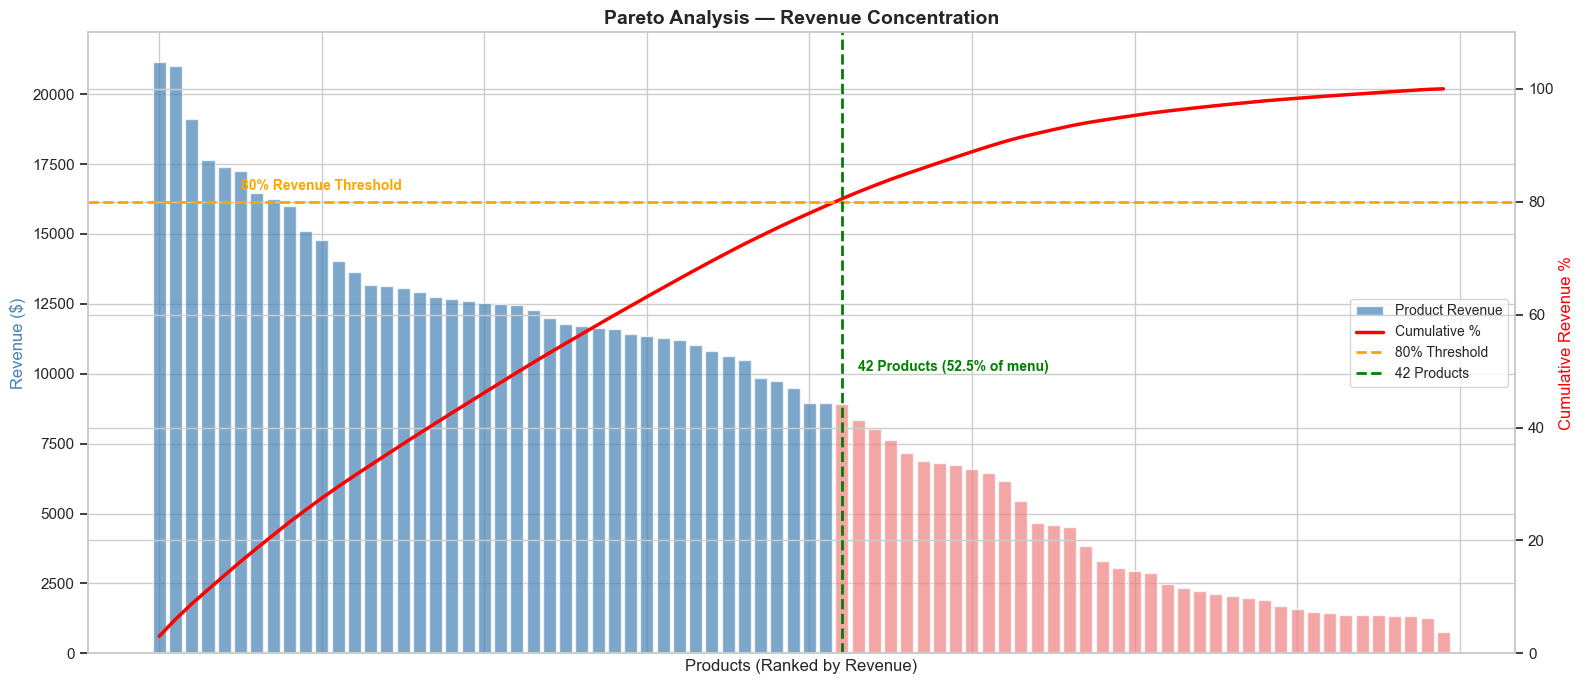

✅ Chart saved as pareto_analysis.png


In [27]:
# Visualize Pareto Analysis

fig, ax1 = plt.subplots(figsize=(16, 7))

# Bar chart - individual product revenue
colors = ['steelblue' if c <= 80 else 'lightcoral'
          for c in pareto_df['cumulative_%']]
ax1.bar(range(len(pareto_df)), pareto_df['total_revenue'],
        color=colors, alpha=0.7, label='Product Revenue')
ax1.set_xlabel('Products (Ranked by Revenue)', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12, color='steelblue')
ax1.tick_params(axis='x', bottom=False, labelbottom=False)

# Line chart - cumulative percentage
ax2 = ax1.twinx()
ax2.plot(range(len(pareto_df)), pareto_df['cumulative_%'],
         color='red', linewidth=2.5, label='Cumulative %')
ax2.axhline(y=80, color='orange', linestyle='--',
            linewidth=2, label='80% Threshold')
ax2.axvline(x=42, color='green', linestyle='--',
            linewidth=2, label='42 Products')
ax2.set_ylabel('Cumulative Revenue %', fontsize=12, color='red')
ax2.set_ylim(0, 110)

# Title and labels
ax1.set_title('Pareto Analysis — Revenue Concentration',
              fontsize=14, fontweight='bold')
ax2.text(5, 82, '80% Revenue Threshold',
         color='orange', fontsize=10, fontweight='bold')
ax2.text(43, 50, '42 Products (52.5% of menu)',
         color='green', fontsize=10, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as pareto_analysis.png")

In [28]:
# ============================================================
# STEP 7: KPI Summary Table
# ============================================================

# KPI 1 & 2: Product Revenue + Volume combined
kpi_product = comparison[['product', 'total_units_sold', 
                           'rank', 'total_revenue', 
                           'revenue_rank', 'revenue_share_%']].copy()

# KPI 5: Product Efficiency Score (Revenue per unit sold)
kpi_product['efficiency_score'] = (
    kpi_product['total_revenue'] / 
    kpi_product['total_units_sold']
).round(2)

# Sort by efficiency score
kpi_efficiency = kpi_product.sort_values(
    'efficiency_score', ascending=False
).reset_index(drop=True)

print("✅ KPI Analysis Complete!")
print(f"\nTop 10 Most Efficient Products (Revenue per Unit):")
print(kpi_efficiency[['product', 'total_units_sold',
                       'total_revenue', 
                       'efficiency_score']].head(10).to_string(index=False))

print(f"\nKPI Summary:")
print(f"Total Revenue              : ${df['revenue'].sum():,.2f}")
print(f"Total Units Sold           : {df['transaction_qty'].sum():,}")
print(f"Total Products             : {kpi_product['product'].nunique()}")
print(f"Revenue Concentration Ratio: 42 products = 80% revenue")
print(f"Top Category               : Coffee (38.63%)")
print(f"Hero Product (Efficiency)  : {kpi_efficiency.iloc[0]['product']}")

✅ KPI Analysis Complete!

Top 10 Most Efficient Products (Revenue per Unit):
                 product  total_units_sold  total_revenue  efficiency_score
               Civet Cat               260       11700.00             45.00
 I Need My Bean! T-shirt               221        6163.00             27.89
     Organic Decaf Blend               206        4657.50             22.61
                Ethiopia               218        4578.00             21.00
    Primo Espresso Roast               150        3067.50             20.45
   Jamacian Coffee River               146        2883.50             19.75
     Brazilian - Organic               214        3852.00             18.00
Our Old Time Diner Blend               183        3294.00             18.00
  Columbian Medium Roast               148        2220.00             15.00
          Espresso Roast               169        2492.75             14.75

KPI Summary:
Total Revenue              : $698,812.33
Total Units Sold           : 214

In [29]:
# ============================================================
# STEP 8: Hero Products Identification
# ============================================================

# Hero product = High volume + High revenue + Good efficiency
# Normalize all scores to 0-100 scale

kpi_hero = kpi_product.copy()

# Normalize each metric (0-100)
kpi_hero['volume_score'] = (
    kpi_hero['total_units_sold'] / 
    kpi_hero['total_units_sold'].max() * 100
).round(2)

kpi_hero['revenue_score'] = (
    kpi_hero['total_revenue'] / 
    kpi_hero['total_revenue'].max() * 100
).round(2)

kpi_hero['efficiency_score_norm'] = (
    kpi_hero['efficiency_score'] / 
    kpi_hero['efficiency_score'].max() * 100
).round(2)

# Hero Score = Average of all three
kpi_hero['hero_score'] = (
    kpi_hero['volume_score'] + 
    kpi_hero['revenue_score'] + 
    kpi_hero['efficiency_score_norm']
) / 3

# Sort by hero score
kpi_hero = kpi_hero.sort_values(
    'hero_score', ascending=False
).reset_index(drop=True)

print("✅ Hero Products Identified!")
print(f"\nTop 10 Hero Products:")
print(kpi_hero[['product', 'total_units_sold',
                'total_revenue', 'efficiency_score',
                'hero_score']].head(10).to_string(index=False))

✅ Hero Products Identified!

Top 10 Hero Products:
                     product  total_units_sold  total_revenue  efficiency_score  hero_score
           Dark chocolate Lg              4668       21006.00              4.50       69.49
Sustainably Grown Organic Lg              4453       21151.75              4.75       68.38
                    Latte Rg              4497       19112.25              4.25       65.11
                       Latte              4602       17257.50              3.75       62.56
     Morning Sunrise Chai Lg              4346       17384.00              4.00       61.13
               Cappuccino Lg              4151       17641.75              4.25       60.34
    Jamaican Coffee River Lg              4395       16481.25              3.75       59.87
Sustainably Grown Organic Rg              4329       16233.75              3.75       59.01
                  Cappuccino              4266       15997.50              3.75       58.19
                Brazilian Lg 

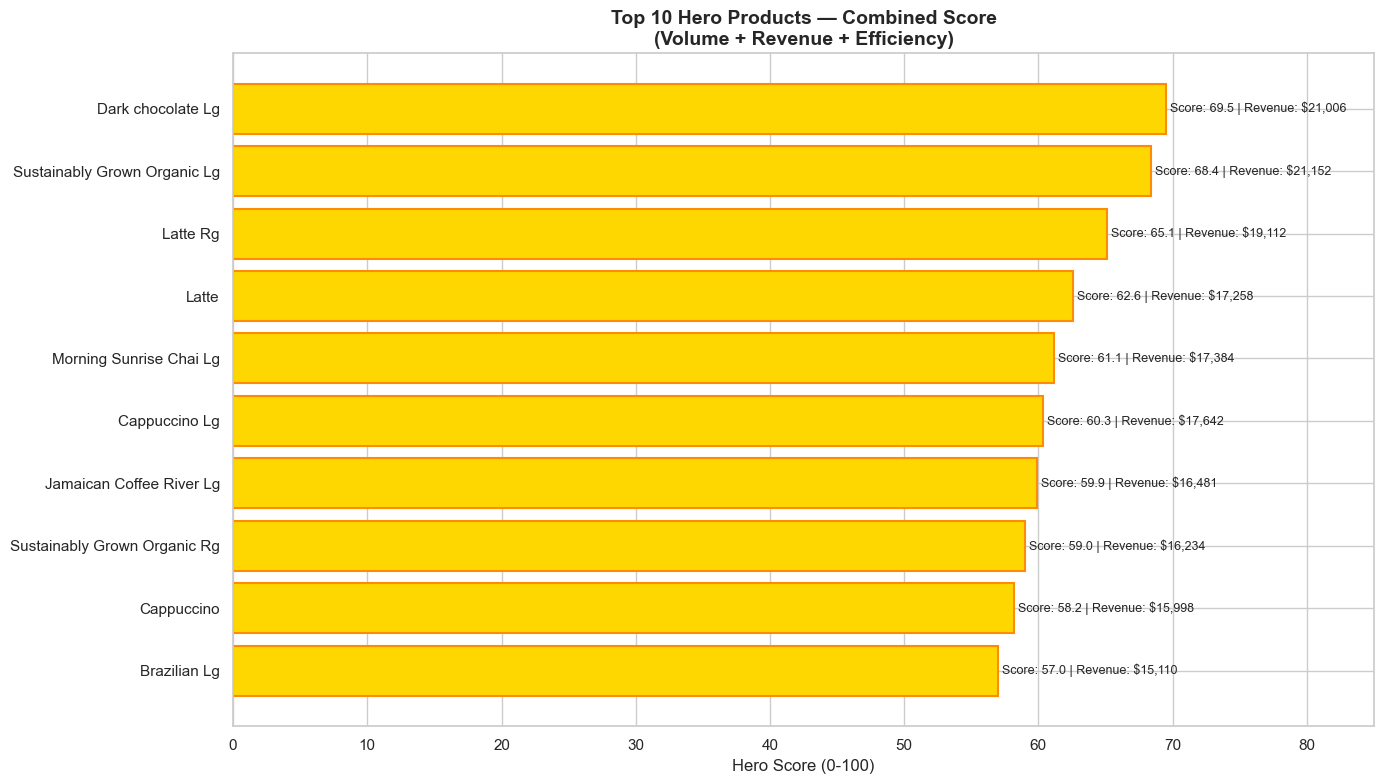

✅ Hero Products Chart saved!


In [30]:
# Visualize Hero Products

fig, ax = plt.subplots(figsize=(14, 8))

top10_hero = kpi_hero.head(10)
bars = ax.barh(top10_hero['product'],
               top10_hero['hero_score'],
               color='gold', edgecolor='darkorange',
               linewidth=1.5)

ax.set_title('Top 10 Hero Products — Combined Score\n(Volume + Revenue + Efficiency)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hero Score (0-100)', fontsize=12)
ax.invert_yaxis()

for i, (score, rev) in enumerate(zip(top10_hero['hero_score'],
                                      top10_hero['total_revenue'])):
    ax.text(score + 0.3, i,
            f'Score: {score:.1f} | Revenue: ${rev:,.0f}',
            va='center', fontsize=9)

ax.set_xlim(0, 85)
plt.tight_layout()
plt.savefig('hero_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Hero Products Chart saved!")